# Llibreries

In [31]:
import pandas as pd
import os
import json


# Visualització
import matplotlib.pyplot as plt
import seaborn as sns

# Config vis
sns.set_theme()

## Dimensions
Carrega del dataset que conté totes les dimensions de les dades

In [19]:
dimensions = pd.read_csv("../data/pad_dimensions.csv")
dim_barris = pd.read_csv("../data/BarcelonaCiutat_Barris.csv")

In [20]:
dim_barris.head()

,codi_districte,nom_districte,codi_barri,nom_barri,geometria_etrs89,geometria_wgs84
0,1,Ciutat Vella,1,el Raval,"POLYGON ((430162.1875 4581936.9845, 430102.838...","POLYGON ((2.16471378585589 41.3859301967194, 2..."
1,1,Ciutat Vella,2,el Barri Gòtic,"POLYGON ((431189.9075 4581851.4475, 431025.789...","POLYGON ((2.1770141884741 41.385248355328, 2.1..."
2,1,Ciutat Vella,3,la Barceloneta,"POLYGON ((432798.7341255 4582081.2599495, 4327...","POLYGON ((2.19622882469513 41.387454220446, 2...."
3,1,Ciutat Vella,4,"Sant Pere, Santa Caterina i la Ribera","POLYGON ((431733.736 4582441.816, 431557.5115 ...","POLYGON ((2.18345134701381 41.3906119681235, 2..."
4,2,Eixample,5,el Fort Pienc,"POLYGON ((431741.8152 4582625.6491, 432012.183...","POLYGON ((2.18352725722411 41.3922683849226, 2..."


## Dades demogràfiques
Aquests datasets seran utilitzats per extreure atributs demogràfic per al conjunt agregat final.
- Població per barri (Recompte)
- Població per continent de nacionalitat (Recompte)
- Estudis Poblacionals per edat i lloc de naixement

#### Població per barri

##### Carrega de dades

In [5]:
# Població

df_poblacio_25 = pd.read_csv('../data/2025_pad_mdbas.csv')
df_poblacio_25.head()

,Data_Referencia,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,AEB,Seccio_Censal,Valor
0,2025-01-01,1,Ciutat Vella,1,el Raval,1,1001,1419
1,2025-01-01,1,Ciutat Vella,1,el Raval,1,1002,1345
2,2025-01-01,1,Ciutat Vella,1,el Raval,2,1003,3710
3,2025-01-01,1,Ciutat Vella,1,el Raval,2,1004,3092
4,2025-01-01,1,Ciutat Vella,1,el Raval,3,1005,2443


In [8]:
df_poblacio_25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Data_Referencia  1068 non-null   object
 1   Codi_Districte   1068 non-null   int64 
 2   Nom_Districte    1068 non-null   object
 3   Codi_Barri       1068 non-null   int64 
 4   Nom_Barri        1068 non-null   object
 5   AEB              1068 non-null   int64 
 6   Seccio_Censal    1068 non-null   int64 
 7   Valor            1068 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 66.9+ KB


**Observacions:**
- No es detecten nuls
- Atribut de valor identificat com a int64 i correcte.
- Poca neteja en general. Són valors absoluts de la població per barri

In [9]:
df_poblacio_25.describe()

,Codi_Districte,Codi_Barri,AEB,Seccio_Censal,Valor
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,5.723783,33.246255,119.857678,5784.427903,1621.784644
std,2.938532,21.892988,65.383709,2939.149880,629.632209
min,1.000000,1.000000,1.000000,1001.000000,784.000000
25%,3.000000,13.000000,63.750000,3040.750000,1327.000000
50%,6.000000,31.000000,122.500000,6036.500000,1531.000000
75%,8.000000,52.000000,175.250000,8092.250000,1775.250000
max,10.000000,73.000000,233.000000,10237.000000,12817.000000


**Observacions:**
- La població mitjana és de 1600 persones per barri, amb una desviació estandard de 629 persones, indicant diferències considerables entre la població dels barris.
- La població mínima és de 784 habitants i la màxima de 12817 habitants.

In [6]:
# Població

df_poblacio_15 = pd.read_csv('../data/2015_pad_mdbas.csv')
df_poblacio_15.head()

,Data_Referencia,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,AEB,Seccio_Censal,Valor
0,2015-01-01,1,Ciutat Vella,1,el Raval,1,1001,1321
1,2015-01-01,1,Ciutat Vella,1,el Raval,1,1002,1528
2,2015-01-01,1,Ciutat Vella,1,el Raval,2,1003,3340
3,2015-01-01,1,Ciutat Vella,1,el Raval,2,1004,2785
4,2015-01-01,1,Ciutat Vella,1,el Raval,3,1005,2460


In [10]:
df_poblacio_15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Data_Referencia  1068 non-null   object
 1   Codi_Districte   1068 non-null   int64 
 2   Nom_Districte    1068 non-null   object
 3   Codi_Barri       1068 non-null   int64 
 4   Nom_Barri        1068 non-null   object
 5   AEB              1068 non-null   int64 
 6   Seccio_Censal    1068 non-null   int64 
 7   Valor            1068 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 66.9+ KB


**Observacions:**
- Mateixes observacions que al dataset de 2025

In [11]:
df_poblacio_15.describe()

,Codi_Districte,Codi_Barri,AEB,Seccio_Censal,Valor
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,5.723783,33.246255,119.857678,5784.427903,1502.528090
std,2.938532,21.892988,65.383709,2939.149880,339.190549
min,1.000000,1.000000,1.000000,1001.000000,542.000000
25%,3.000000,13.000000,63.750000,3040.750000,1256.750000
50%,6.000000,31.000000,122.500000,6036.500000,1457.000000
75%,8.000000,52.000000,175.250000,8092.250000,1669.250000
max,10.000000,73.000000,233.000000,10237.000000,3414.000000


**Observacions:**
- La població mitjana és de 1502 persones per barri, amb una desviació estandard de 329 persones, indicant que les distribucions eren més homogènies al 2015.
- La població mínima és de 784 habitants i la màxima de 3414 habitants.
- En base als números de 2025 vs 2015, hi ha indicadors de que la població ha crescut en un nombre reduït de barris (Max de 3414 a 12817) però en els altres s' ha mantingut (Mitjana de 1502 a 1620).

##### Neteja
- Convertir valors a int32 per temes de memòria.
- Agrupacions a nivell de barri.

In [12]:
# Convertir la columna "Valor" a int32
df_poblacio_25["Valor"] = df_poblacio_25["Valor"].astype("Int32")
df_poblacio_15["Valor"] = df_poblacio_15["Valor"].astype("Int32")

In [16]:
# Agregar a població per barri
df_poblacio_15_agg = df_poblacio_15.groupby(["Codi_Districte", "Codi_Barri"]).agg({"Valor": "sum"}).reset_index()
df_poblacio_25_agg = df_poblacio_25.groupby(["Codi_Districte", "Codi_Barri"]).agg({"Valor": "sum"}).reset_index()

In [17]:
df_poblacio_15_agg.head()

,Codi_Districte,Codi_Barri,Valor
0,1,1,47150
1,1,2,15514
2,1,3,15037
3,1,4,22468
4,2,5,31548


In [18]:
df_poblacio_25_agg.head()

,Codi_Districte,Codi_Barri,Valor
0,1,1,49917
1,1,2,27878
2,1,3,14749
3,1,4,22767
4,2,5,36621


In [23]:
# Merge dels dos datasets
df_poblacio = pd.merge(df_poblacio_15_agg, df_poblacio_25_agg, on=["Codi_Districte", "Codi_Barri"], suffixes=("_2015", "_2025"))
df_poblacio.head()

,Codi_Districte,Codi_Barri,Valor_2015,Valor_2025
0,1,1,47150,49917
1,1,2,15514,27878
2,1,3,15037,14749
3,1,4,22468,22767
4,2,5,31548,36621


##### EDA (Anàlisi exploratòria de dades)

In [25]:
df_poblacio_temp = pd.merge(df_poblacio, dim_barris, left_on=["Codi_Districte", "Codi_Barri"], right_on=["codi_districte", "codi_barri"], how="left")
df_poblacio_temp.head()

,Codi_Districte,Codi_Barri,Valor_2015,Valor_2025,codi_districte,nom_districte,codi_barri,nom_barri,geometria_etrs89,geometria_wgs84
0,1,1,47150,49917,1,Ciutat Vella,1,el Raval,"POLYGON ((430162.1875 4581936.9845, 430102.838...","POLYGON ((2.16471378585589 41.3859301967194, 2..."
1,1,2,15514,27878,1,Ciutat Vella,2,el Barri Gòtic,"POLYGON ((431189.9075 4581851.4475, 431025.789...","POLYGON ((2.1770141884741 41.385248355328, 2.1..."
2,1,3,15037,14749,1,Ciutat Vella,3,la Barceloneta,"POLYGON ((432798.7341255 4582081.2599495, 4327...","POLYGON ((2.19622882469513 41.387454220446, 2...."
3,1,4,22468,22767,1,Ciutat Vella,4,"Sant Pere, Santa Caterina i la Ribera","POLYGON ((431733.736 4582441.816, 431557.5115 ...","POLYGON ((2.18345134701381 41.3906119681235, 2..."
4,2,5,31548,36621,2,Eixample,5,el Fort Pienc,"POLYGON ((431741.8152 4582625.6491, 432012.183...","POLYGON ((2.18352725722411 41.3922683849226, 2..."


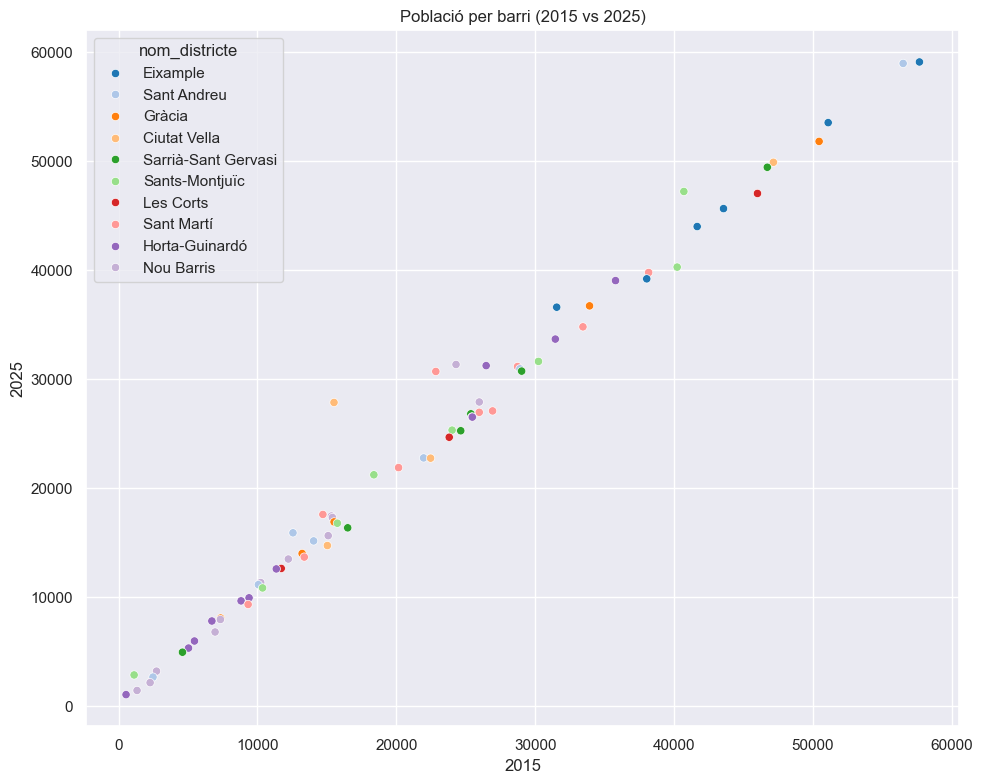

In [42]:
pobs_ordenades = df_poblacio_temp.sort_values(by="Valor_2025", ascending = False)
plt.figure(figsize=(10,8))
sns.scatterplot(data = pobs_ordenades, x= "Valor_2015", y= "Valor_2025", hue="nom_districte", legend= True, palette="tab20")
plt.title("Població per barri (2015 vs 2025)")
plt.xlabel("2015")
plt.ylabel("2025")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Població per barri (2015 vs 2025)'}, xlabel='Barri', ylabel='Població'>

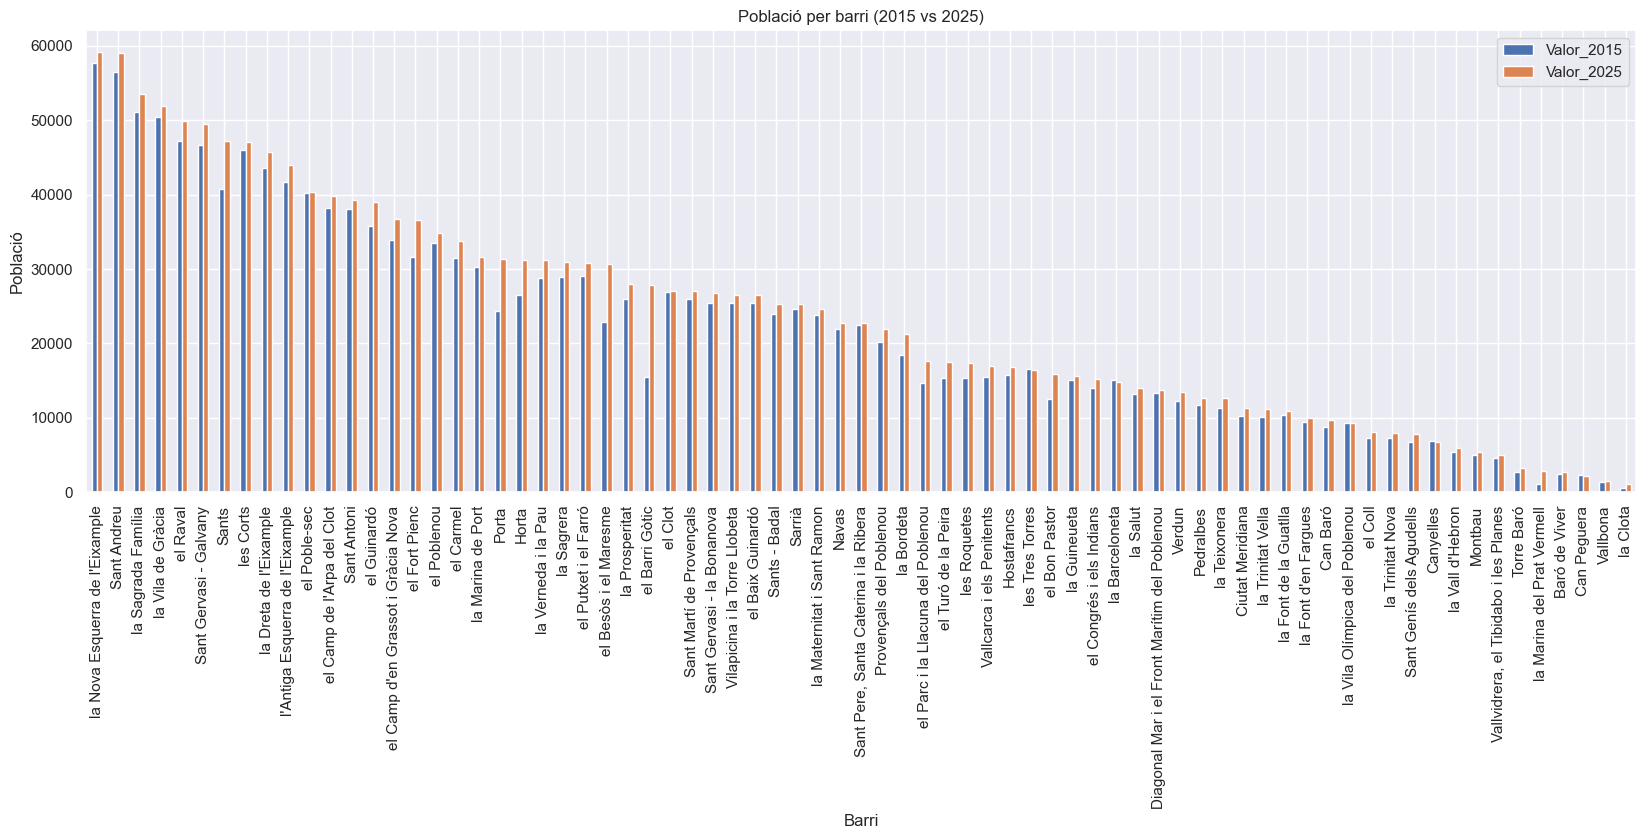

In [34]:
df_poblacio_temp.sort_values(by="Valor_2025", ascending=False).plot(kind= 'bar', 
                      x = "nom_barri", 
                      y = ["Valor_2015", "Valor_2025"], 
                      figsize=(20, 6), 
                      title="Població per barri (2015 vs 2025)", 
                      ylabel="Població", 
                      xlabel="Barri")